In [1]:
import numpy as np
import time
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from itertools import combinations_with_replacement as cb

In [2]:
def lotka_volterra(t, state, alpha, beta, delta, gamma):
    prey, predator = state
    return [alpha*prey - beta*prey*predator, delta*prey*predator - gamma*predator]

def build_library_degree2(data):
    n = data.shape[0]
    prey = data[:,0]
    predator = data[:,1]
    return np.column_stack([
        np.ones(n), prey, predator, prey**2, prey*predator, predator**2
    ])

def build_library_general(data, degree):
    n = data.shape[0]
    library = [np.ones(n)]
    for d in range(1, degree+1):
        for combo in cb([0,1], d):
            library.append(np.prod(data[:, list(combo)], axis=1))
    return np.column_stack(library)

def stls(library, derivatives, threshold, max_iter=10):
    try:
        coeffs = np.linalg.lstsq(library, derivatives, rcond=None)[0]
        for _ in range(max_iter):
            small_mask = np.abs(coeffs) <= threshold
            coeffs[small_mask] = 0
            for col in range(derivatives.shape[1]):
                keep = ~small_mask[:, col]
                if np.any(keep):
                    coeffs[keep, col] = np.linalg.lstsq(library[:, keep], derivatives[:, col], rcond=None)[0]
        return coeffs
    except:
        return np.nan * np.ones((library.shape[1], derivatives.shape[1]))

In [3]:
alpha, beta, delta, gamma = 1.0, 0.1, 0.05, 1.5
initial_state = [40, 9]
time_span = [0, 50]
dt = 0.01
time_points = np.arange(time_span[0], time_span[1], dt)

solution = solve_ivp(lotka_volterra, time_span, initial_state,
                     args=(alpha, beta, delta, gamma),
                     t_eval=time_points)

state_data = solution.y.T
derivatives = np.array([lotka_volterra(0, s, alpha, beta, delta, gamma) for s in state_data])

In [4]:
library_deg2 = build_library_degree2(state_data)

reference_lambda = 0.01
true_coeffs = stls(library_deg2, derivatives, reference_lambda)

terms = ['1','prey','pred','prey^2','prey*pred','pred^2']

print("\n--- clean recovery (lambda=0.01) ---")
print(f"{'term':<10} {'dprey':<10} {'dpred':<10}")

for i, term in enumerate(terms):
    print(f"{term:<10} {true_coeffs[i,0]:>10.4f} {true_coeffs[i,1]:>10.4f}")


--- clean recovery (lambda=0.01) ---
term       dprey      dpred     
1              0.0000     0.0000
prey           1.0000     0.0000
pred           0.0000    -1.5000
prey^2         0.0000     0.0000
prey*pred     -0.1000     0.0500
pred^2         0.0000     0.0000


In [5]:
np.random.seed(42)

noise_levels = [0.0, 0.01, 0.1, 0.5, 1.0]
lambda_values = [0.01, 0.05, 0.1, 0.5, 1.0]

noise_results = []

for noise_level in noise_levels:
    noise = noise_level * np.random.randn(*derivatives.shape)
    noisy_derivatives = derivatives + noise
    
    for lam in lambda_values:
        noisy_coeffs = stls(library_deg2, noisy_derivatives, lam)
        error = np.linalg.norm(true_coeffs - noisy_coeffs)
        noise_results.append((noise_level, lam, error))

print("\n--- noise test (noise=0.1) ---")
print(f"{'lambda':<10} | {'error':<10}")
print("-"*30)

for r in noise_results:
    if r[0] == 0.1:
        print(f"{r[1]:<10} | {r[2]:.6f}")


--- noise test (noise=0.1) ---
lambda     | error     
------------------------------
0.01       | 0.000638
0.05       | 1.500833
0.1        | 1.806239
0.5        | 1.806239
1.0        | 1.806239


In [6]:
degrees = [1,2,3,4,5]
lambda_val = 0.05
noise_level = 0.1

np.random.seed(42)
noisy_derivatives = derivatives + noise_level * np.random.randn(*derivatives.shape)

print("\n--- degree sweep ---")
print(f"{'deg':<5} | {'terms':<6} | {'ms':<8} | {'err_clean':<10} | {'err_noisy':<10}")
print("-"*55)

for degree in degrees:
    library = build_library_general(state_data, degree)
    
    true_model = np.zeros((library.shape[1], 2))
    if degree >= 1:
        true_model[1,0], true_model[2,1] = 1.0, -1.5
    if degree >= 2:
        true_model[4,0], true_model[4,1] = -0.1, 0.05

    t_start = time.perf_counter()
    coeffs_clean = stls(library, derivatives, lambda_val)
    t_end = time.perf_counter()
    coeffs_noisy = stls(library, noisy_derivatives, lambda_val)

    error_clean = np.linalg.norm(coeffs_clean - true_model)
    error_noisy = np.linalg.norm(coeffs_noisy - true_model)

    print(f"{degree:<5} | {library.shape[1]:<6} | {(t_end-t_start)*1000:<8.2f} | {error_clean:<10.4f} | {error_noisy:<10.4f}")


--- degree sweep ---
deg   | terms  | ms       | err_clean  | err_noisy 
-------------------------------------------------------
1     | 3      | 2.04     | 33.7097    | 33.7153   
2     | 6      | 1.85     | 0.0000     | 0.0007    
3     | 10     | 1.97     | 0.0000     | 1.5008    
4     | 15     | 2.30     | 0.0000     | 0.0007    
5     | 21     | 2.72     | 15.1530    | 0.0007    


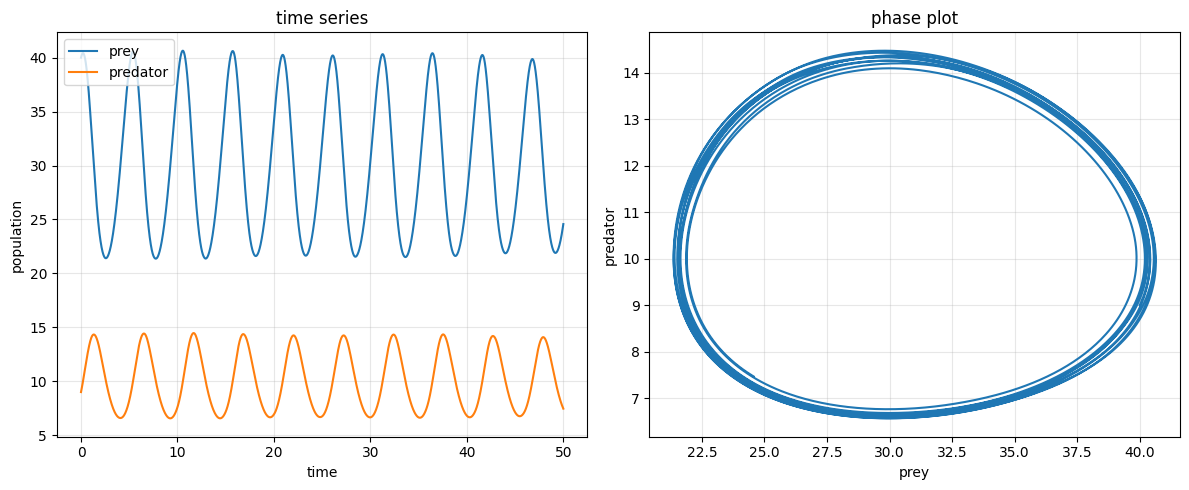

In [7]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(time_points, state_data[:,0], label='prey')
plt.plot(time_points, state_data[:,1], label='predator')
plt.xlabel('time')
plt.ylabel('population')
plt.title('time series')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.plot(state_data[:,0], state_data[:,1])
plt.xlabel('prey')
plt.ylabel('predator')
plt.title('phase plot')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()